Dataset URL: https://www.kaggle.com/datasets/hellbuoy/online-retail-customer-clustering
License(s): unknown
online-retail-customer-clustering.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  online-retail-customer-clustering.zip
  inflating: OnlineRetail.csv        
Dataset Shape: (541909, 8)
After removing null values: (406829, 8)


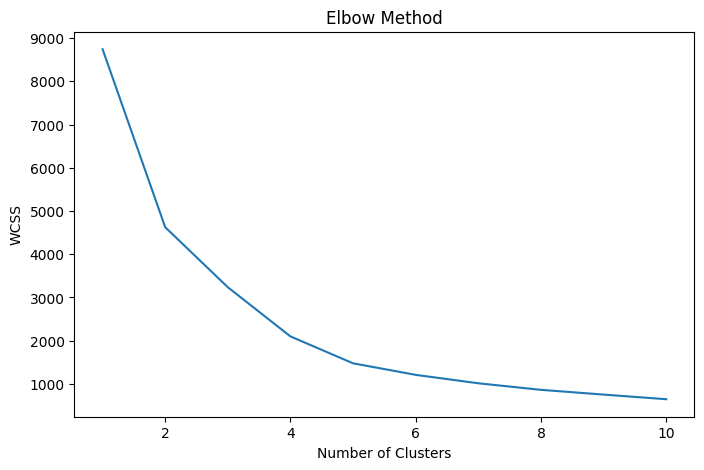


Cluster Analysis:
           CustomerID     TotalSpent  TotalOrders
Cluster                                          
0        15303.928391     963.993460    54.480333
1        14899.000000   64776.602500  5914.000000
2        15258.070130    6755.788571   389.155844
3        16732.666667  241136.560000   956.333333
4        15047.142857   63812.361429  1029.285714


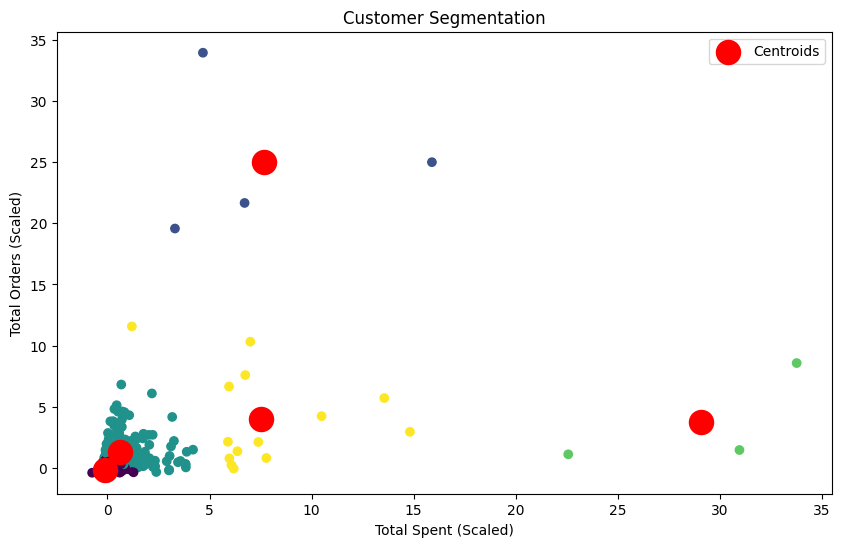

Silhouette Score: 0.7667964829064765
Model Saved Successfully!
New Customer belongs to Cluster: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:

import os

os.environ["KAGGLE_USERNAME"] = "kanakgoyal01"
os.environ["KAGGLE_KEY"] = "f58621c1b27a7a854dd808e2b036c366"

!kaggle datasets download -d hellbuoy/online-retail-customer-clustering

!unzip -o online-retail-customer-clustering.zip


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

print("Dataset Shape:", df.shape)
df.head()



df = df.dropna()

print("After removing null values:", df.shape)



df['TotalAmount'] = df['Quantity'] * df['UnitPrice']


customer_df = df.groupby('CustomerID').agg({
    'TotalAmount': 'sum',
    'InvoiceNo': 'count'
}).reset_index()

customer_df.columns = ['CustomerID', 'TotalSpent', 'TotalOrders']

customer_df.head()


X = customer_df[['TotalSpent', 'TotalOrders']]



from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)


customer_df['Cluster'] = y_kmeans

customer_df.head()


print("\nCluster Analysis:")
print(customer_df.groupby('Cluster').mean())


plt.figure(figsize=(10,6))

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans, cmap='viridis')

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='red',
    label='Centroids'
)

plt.title("Customer Segmentation")
plt.xlabel("Total Spent (Scaled)")
plt.ylabel("Total Orders (Scaled)")
plt.legend()

plt.show()

0
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_kmeans)

print("Silhouette Score:", score)



import pickle

pickle.dump(kmeans, open('customer_segmentation_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Model Saved Successfully!")


model = pickle.load(open('customer_segmentation_model.pkl', 'rb'))



new_customer = [[5000, 10]]

new_customer_scaled = scaler.transform(new_customer)

cluster = model.predict(new_customer_scaled)

print("New Customer belongs to Cluster:", cluster)



In [ ]:

pickle.dump(scaler, open('scaler.pkl', 'wb'))


customer_df.to_csv("customer_data.csv", index=False)

print("Scaler + Dataset Saved!")

Scaler + Dataset Saved!


In [ ]:
pickle.dump(kmeans, open('customer_segmentation_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
customer_df.to_csv("customer_data.csv", index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')